# Preprocessing Dataset: Real vs AI Face (Versi Bersih)

Notebook ini adalah hasil rapikan dari eksperimen mitigasi bias dataset. Alur yang dipakai:

1. Standarisasi resolusi & kompresi awal (`dataset_clean`)
2. Sanity check: cek apakah ukuran file/metadata bisa jadi shortcut classifier
3. Face cropping dengan Dlib (margin 0.2) → `dataset_cropped`
4. Equalize ukuran file (binary search JPEG quality) → **`dataset_final`** (dataset yang dipakai untuk training & sudah divalidasi: permutation test, 5-fold CV, feature ablation)
5. Simpan `dataset_final` ke Google Drive

> Catatan: eksperimen crop margin ketat (0.05) dan noise-injection sengaja **tidak** dimasukkan lagi ke notebook ini karena noise-injection terbukti backfire (menaikkan bias, bukan menurunkan), dan tight-crop tidak pernah dilanjutkan sampai jadi dataset final.

## 1. Setup & Import

In [ ]:
import os
import time
import shutil
import urllib.request
import bz2
from io import BytesIO

import numpy as np
import cv2
import dlib
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

IMG_SIZE = (128, 128)

# Download model landmark Dlib (dibutuhkan untuk face detection saat cropping)
model_path = "shape_predictor_68_face_landmarks.dat"
if not os.path.exists(model_path):
    print("Mengunduh model Dlib 68 Facial Landmarks...")
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    urllib.request.urlretrieve(url, model_path + ".bz2")
    with bz2.BZ2File(model_path + ".bz2", 'rb') as source, open(model_path, 'wb') as dest:
        dest.write(source.read())
    os.remove(model_path + ".bz2")
    print("Download selesai!\n")
else:
    print("Model Dlib sudah tersedia.\n")

detector = dlib.get_frontal_face_detector()

Model Dlib sudah tersedia.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path dataset MENTAH (foto asli sebelum diproses apapun)
raw_base_path = '/content/drive/MyDrive/Tubes_RF/dataset_clean'
raw_real_path = os.path.join(raw_base_path, 'real')
raw_ai_path = os.path.join(raw_base_path, 'ai')

print(f"Path Real (mentah): {raw_real_path}")
print(f"Path AI (mentah): {raw_ai_path}")

Mounted at /content/drive
Path Real (mentah): /content/drive/MyDrive/Tubes_RF/dataset_clean/real
Path AI (mentah): /content/drive/MyDrive/Tubes_RF/dataset_clean/ai


## 2. Tahap 1 — Standarisasi Resolusi & Kompresi Awal

Menyamakan semua foto ke resolusi 256x256 dan JPEG quality 75, supaya tidak ada bias resolusi/format yang mencolok (foto Real awalnya PNG kecil, foto AI JPG besar & seragam 512x512).

In [ ]:
def standardize_folder(src_folder, dst_folder, quality=75, target_size=(256, 256)):
    os.makedirs(dst_folder, exist_ok=True)
    files = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in tqdm(files, desc=f"Standarisasi {src_folder}"):
        try:
            img = Image.open(os.path.join(src_folder, f)).convert('RGB')
            img = img.resize(target_size, Image.LANCZOS)
            new_name = os.path.splitext(f)[0] + '.jpg'
            img.save(os.path.join(dst_folder, new_name), 'JPEG', quality=quality)
        except Exception as e:
            print(f"Gagal: {f} - {e}")

real_clean = '/content/dataset_clean/real'
ai_clean = '/content/dataset_clean/ai'

standardize_folder(raw_real_path, real_clean, quality=75, target_size=(256, 256))
standardize_folder(raw_ai_path, ai_clean, quality=75, target_size=(256, 256))

Standarisasi /content/drive/MyDrive/Tubes_RF/dataset_clean/real: 100%|██████████| 2000/2000 [00:59<00:00, 33.49it/s] 
Standarisasi /content/drive/MyDrive/Tubes_RF/dataset_clean/ai: 100%|██████████| 2000/2000 [01:00<00:00, 33.30it/s] 


## 3. Sanity Check — Fungsi Bantuan (dipakai berulang di beberapa tahap)

In [ ]:
def get_size_stats(folder_path, label):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg'))]
    sizes_kb = [os.path.getsize(os.path.join(folder_path, f)) / 1024 for f in files]
    print(f"{label}: mean={np.mean(sizes_kb):.1f}KB, median={np.median(sizes_kb):.1f}KB, "
          f"std={np.std(sizes_kb):.1f}KB, min={np.min(sizes_kb):.1f}KB, max={np.max(sizes_kb):.1f}KB")

def check_dimensions(folder_path, label, sample_size=50):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg'))][:sample_size]
    dims = [Image.open(os.path.join(folder_path, f)).size for f in files]
    widths = [d[0] for d in dims]
    heights = [d[1] for d in dims]
    print(f"{label}: width min-max = {min(widths)}-{max(widths)}, height min-max = {min(heights)}-{max(heights)}")

def get_sizes_and_labels(real_folder, ai_folder):
    real_files = [f for f in os.listdir(real_folder) if f.lower().endswith(('.jpg', '.jpeg'))]
    ai_files = [f for f in os.listdir(ai_folder) if f.lower().endswith(('.jpg', '.jpeg'))]
    real_sizes = [os.path.getsize(os.path.join(real_folder, f)) for f in real_files]
    ai_sizes = [os.path.getsize(os.path.join(ai_folder, f)) for f in ai_files]
    X = np.array(real_sizes + ai_sizes).reshape(-1, 1)
    y = np.array([0]*len(real_sizes) + [1]*len(ai_sizes))
    return X, y

def sanity_check_filesize(real_folder, ai_folder, label=""):
    """Latih logistic regression HANYA dari ukuran file - cek apakah ini jadi shortcut classifier"""
    X, y = get_sizes_and_labels(real_folder, ai_folder)
    clf = LogisticRegression()
    scores = cross_val_score(clf, X, y, cv=5)
    print(f"Akurasi HANYA dari ukuran file {label}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

In [ ]:
check_dimensions(real_clean, "Real")
check_dimensions(ai_clean, "AI")
get_size_stats(real_clean, "Real")
get_size_stats(ai_clean, "AI")
sanity_check_filesize(real_clean, ai_clean, label="(dataset_clean)")

Real: width min-max = 256-256, height min-max = 256-256
AI: width min-max = 256-256, height min-max = 256-256
Real: mean=8.3KB, median=7.9KB, std=2.2KB, min=3.8KB, max=13.6KB
AI: mean=11.0KB, median=11.3KB, std=1.5KB, min=6.8KB, max=13.5KB
Akurasi HANYA dari ukuran file (dataset_clean): 74.90% (+/- 1.01%)


## 4. Tahap 2 — Face Cropping (Dlib, margin 0.2)

**Penting:** urutan sudah diperbaiki — crop wajah dilakukan SEBELUM equalize ukuran file (equalize duluan sempat bikin Dlib gagal deteksi wajah karena over-compression).

In [ ]:
def load_crop_and_normalize(folder_path, label, margin_ratio=0.2):
    images, labels = [], []
    skipped_count = 0
    valid_extensions = ('.jpg', '.jpeg', '.png')
    file_names = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

    for filename in tqdm(file_names, desc=f"Loading Label {label}"):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is None:
            skipped_count += 1
            continue

        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = detector(img_gray, 1)

        if len(faces) > 0:
            face = faces[0]
            x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
            margin_x = int(margin_ratio * (x2 - x1))
            margin_y = int(margin_ratio * (y2 - y1))
            x1 = max(0, x1 - margin_x)
            y1 = max(0, y1 - margin_y)
            x2 = min(img.shape[1], x2 + margin_x)
            y2 = min(img.shape[0], y2 + margin_y)

            cropped_face = img_gray[y1:y2, x1:x2]
            img_resized = cv2.resize(cropped_face, IMG_SIZE)
            images.append(img_resized)
            labels.append(label)
        else:
            skipped_count += 1

    print(f"\nLabel {label} - Di-skip: {skipped_count} gambar karena wajah tidak terdeteksi.")
    return images, labels

real_images, real_labels = load_crop_and_normalize(real_clean, label=0, margin_ratio=0.2)
ai_images, ai_labels = load_crop_and_normalize(ai_clean, label=1, margin_ratio=0.2)

print(f"\nWajah terdeteksi - Real: {len(real_images)}, AI: {len(ai_images)}")

Loading Label 0: 100%|██████████| 2000/2000 [01:29<00:00, 22.26it/s]



Label 0 - Di-skip: 246 gambar karena wajah tidak terdeteksi.


Loading Label 1: 100%|██████████| 2000/2000 [01:29<00:00, 22.29it/s]


Label 1 - Di-skip: 0 gambar karena wajah tidak terdeteksi.

Wajah terdeteksi - Real: 1754, AI: 2000


In [ ]:
def save_images_to_folder(images, folder):
    os.makedirs(folder, exist_ok=True)
    for i, img in enumerate(images):
        Image.fromarray(img).save(os.path.join(folder, f"crop_{i}.jpg"), quality=95)
    print(f"Tersimpan {len(images)} gambar di {folder}")

real_cropped = '/content/dataset_cropped/real'
ai_cropped = '/content/dataset_cropped/ai'

save_images_to_folder(real_images, real_cropped)
save_images_to_folder(ai_images, ai_cropped)

get_size_stats(real_cropped, "Real (cropped)")
get_size_stats(ai_cropped, "AI (cropped)")

Tersimpan 1754 gambar di /content/dataset_cropped/real
Tersimpan 2000 gambar di /content/dataset_cropped/ai
Real (cropped): mean=6.1KB, median=5.9KB, std=1.3KB, min=3.1KB, max=9.5KB
AI (cropped): mean=7.2KB, median=7.3KB, std=0.7KB, min=4.7KB, max=8.8KB


## 5. Tahap 3 — Equalize Ukuran File (target ~6.15 KB, quality_range 60-95)

`quality_range` dibatasi minimum 60 (bukan 20) supaya tidak over-compress sampai wajah rusak dan gagal dideteksi ulang di tahap ekstraksi fitur (landmark).

In [ ]:
def compress_to_target_size(img, target_kb, tolerance_kb=0.5, quality_range=(60, 95)):
    low, high = quality_range
    best_buffer = None
    for _ in range(8):
        mid = (low + high) // 2
        buffer = BytesIO()
        img.save(buffer, 'JPEG', quality=mid)
        size_kb = buffer.tell() / 1024
        if abs(size_kb - target_kb) <= tolerance_kb:
            best_buffer = buffer
            break
        elif size_kb > target_kb:
            high = mid - 1
        else:
            low = mid + 1
        best_buffer = buffer
    return best_buffer

def equalize_folder(src_folder, dst_folder, target_kb, tolerance_kb=0.5, quality_range=(60, 95)):
    os.makedirs(dst_folder, exist_ok=True)
    files = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in tqdm(files, desc=f"Equalizing {src_folder}"):
        try:
            img = Image.open(os.path.join(src_folder, f)).convert('RGB')
            buffer = compress_to_target_size(img, target_kb, tolerance_kb, quality_range)
            new_name = os.path.splitext(f)[0] + '.jpg'
            with open(os.path.join(dst_folder, new_name), 'wb') as out:
                out.write(buffer.getvalue())
        except Exception as e:
            print(f"Gagal: {f} - {e}")

target_kb = 6.15  # titik tengah mean Real (5.8KB) & AI (6.5KB) hasil crop

real_final = '/content/dataset_final/real'
ai_final = '/content/dataset_final/ai'

equalize_folder(real_cropped, real_final, target_kb, quality_range=(60, 95))
equalize_folder(ai_cropped, ai_final, target_kb, quality_range=(60, 95))

Equalizing /content/dataset_cropped/ai: 100%|██████████| 2000/2000 [00:02<00:00, 778.29it/s]


In [ ]:
# Verifikasi akhir sebelum dipakai untuk training
get_size_stats(real_final, "Real (final)")
get_size_stats(ai_final, "AI (final)")
sanity_check_filesize(real_final, ai_final, label="(dataset_final)")

print(f"\nJumlah file final - Real: {len(os.listdir(real_final))}, AI: {len(os.listdir(ai_final))}")

Real (final): mean=5.7KB, median=5.8KB, std=0.6KB, min=3.5KB, max=6.6KB
AI (final): mean=6.2KB, median=6.3KB, std=0.3KB, min=5.1KB, max=6.6KB
Akurasi HANYA dari ukuran file (dataset_final): 70.67% (+/- 1.30%)

Jumlah file final - Real: 1754, AI: 2000


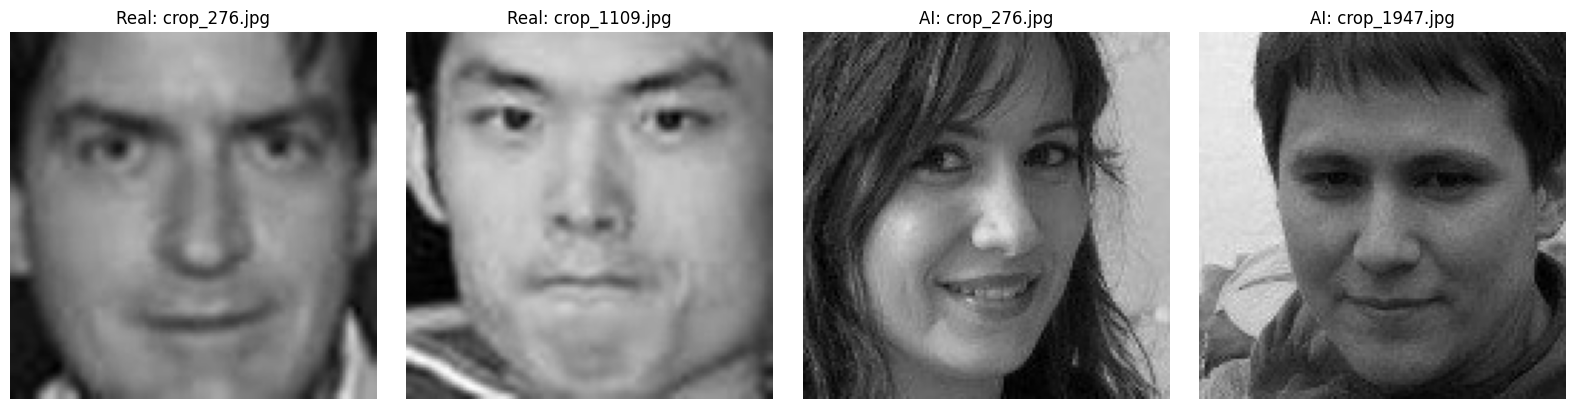

In [ ]:
# Cek visual - pastikan wajah masih terlihat jelas, tidak rusak/blocky
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_files_real = os.listdir(real_final)[:2]
sample_files_ai = os.listdir(ai_final)[:2]

for i, f in enumerate(sample_files_real):
    img = Image.open(os.path.join(real_final, f))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Real: {f}')
    axes[i].axis('off')

for i, f in enumerate(sample_files_ai):
    img = Image.open(os.path.join(ai_final, f))
    axes[i+2].imshow(img, cmap='gray')
    axes[i+2].set_title(f'AI: {f}')
    axes[i+2].axis('off')

plt.tight_layout()
plt.show()

## 6. Simpan `dataset_final` ke Google Drive

In [ ]:
import shutil
from google.colab import files

# Zip folder hasil crop+equalize yang ada di /content/ (lokal Colab)
shutil.make_archive('/content/dataset_final', 'zip', '/content/dataset_final')

# Download langsung ke laptop
files.download('/content/dataset_final.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>